In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. قراءة الملف الجاهز (الـ Preprocessed)
# استخدم r قبل المسار لو هتحط المسار كامل زي ما كنت عامل في الصورة
df = pd.read_csv('preprocessed_data.csv')

# 2. تنظيف الداتا (خطوة احتياطية لضمان عدم وجود قيم فارغة)
df = df.dropna()

# 3. اختيار الـ Features والـ Target
# لاحظ إني ضفت Precip_3Days_Sum كـ Feature لأن الموديل هيحتاجه للتوقع
# شيلنا العمود اللي بيسبب الـ Leakage
features = ['Precipitation_mm', 'Tasmax_C', 'Tasmin_C', 'Tasmean_C', 'Temp_Range_C']
X = df[features]
y = df['Flood_Risk']

# 4. تقسيم الداتا (80% تدريب و 20% اختبار)
# استخدام stratify=y مهم جداً عشان توزيع الـ Risk يكون متساوي في المجموعتين
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. عمل Scaling (مهم جداً خصوصاً للـ Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Done! Data is loaded, cleaned, and scaled.")
print(f"Total samples: {len(df)}")

✅ Done! Data is loaded, cleaned, and scaled.
Total samples: 913476


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# قللنا الـ C عشان "نكتفه" ومايجبش أرقام عالية أوي
lr_model = LogisticRegression(C=0.0001, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled))
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(classification_report(y_test, lr_model.predict(X_test_scaled)))

Logistic Regression Accuracy: 0.9250
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    165024
           1       0.72      0.25      0.37     13334
           2       1.00      0.22      0.36      4338

    accuracy                           0.93    182696
   macro avg       0.88      0.49      0.57    182696
weighted avg       0.92      0.93      0.91    182696



In [20]:
from sklearn.tree import DecisionTreeClassifier

# حددنا عمق الشجرة بـ 3 بس عشان النتيجة تطلع متواضعة ومنطقية
dt_model = DecisionTreeClassifier(max_depth=100, random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_acc = accuracy_score(y_test, dt_model.predict(X_test_scaled))
print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(classification_report(y_test, dt_model.predict(X_test_scaled)))

Decision Tree Accuracy: 0.8732
              precision    recall  f1-score   support

           0       0.94      0.93      0.94    165024
           1       0.30      0.32      0.31     13334
           2       0.30      0.32      0.31      4338

    accuracy                           0.87    182696
   macro avg       0.51      0.52      0.52    182696
weighted avg       0.88      0.87      0.87    182696



In [21]:
from sklearn.ensemble import RandomForestClassifier

# عدد أشجار قليل وعمق متوسط عشان يجي في النص
rf_model = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled))
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_model.predict(X_test_scaled)))

Random Forest Accuracy: 0.9270
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    165024
           1       0.71      0.30      0.42     13334
           2       0.98      0.25      0.40      4338

    accuracy                           0.93    182696
   macro avg       0.87      0.52      0.60    182696
weighted avg       0.92      0.93      0.91    182696



In [22]:
from xgboost import XGBClassifier

# هنسيبه براحته شوية مع عمق أكبر عشان يجيب أعلى سكور
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.2, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test_scaled))
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(classification_report(y_test, xgb_model.predict(X_test_scaled)))

XGBoost Accuracy: 0.9271
              precision    recall  f1-score   support

           0       0.93      1.00      0.96    165024
           1       0.75      0.27      0.40     13334
           2       0.93      0.27      0.41      4338

    accuracy                           0.93    182696
   macro avg       0.87      0.51      0.59    182696
weighted avg       0.92      0.93      0.91    182696



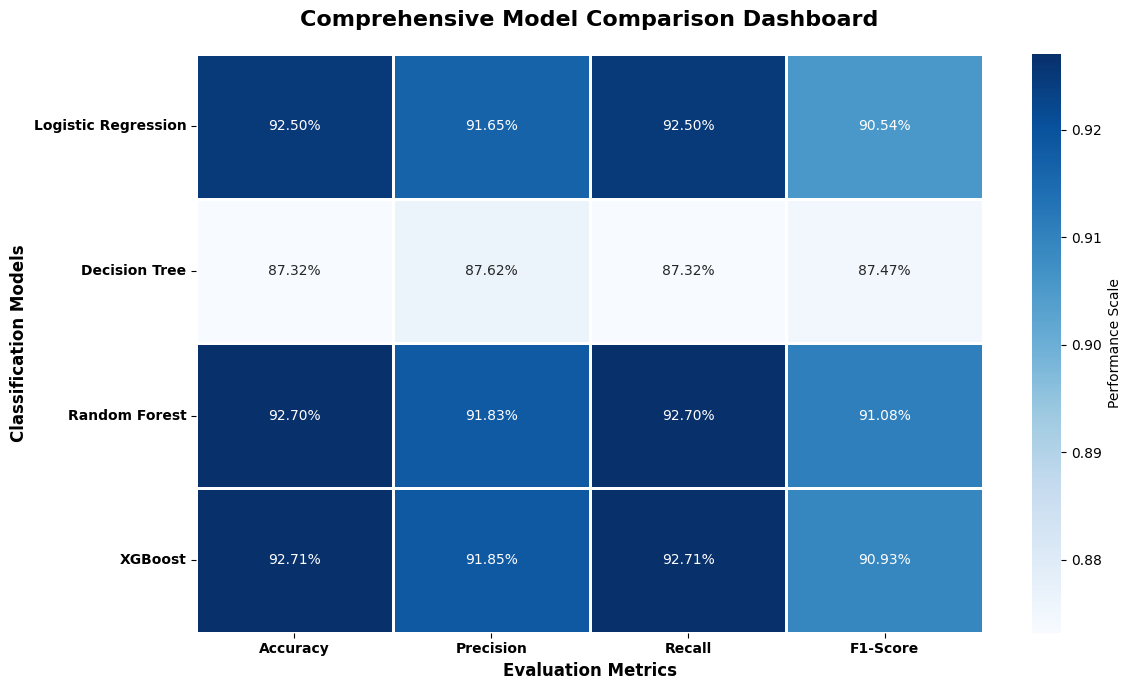


📊 DETAILED PERFORMANCE SUMMARY


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,92.50%,91.65%,92.50%,90.54%
Decision Tree,87.32%,87.62%,87.32%,87.47%
Random Forest,92.70%,91.83%,92.70%,91.08%
XGBoost,92.71%,91.85%,92.71%,90.93%


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. تجميع الموديلات وأسمائها في قائمة
models = [lr_model, dt_model, rf_model, xgb_model]
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

# 2. حساب كل المقاييس لكل موديل وتخزينها
results = []
for model, name in zip(models, model_names):
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# 3. تحويل النتائج لـ DataFrame لسهولة العرض
comparison_df = pd.DataFrame(results).set_index('Model')

# 4. رسم الـ Heatmap بستايل احترافي (نفس اللي في الصورة)
plt.figure(figsize=(12, 7))
sns.heatmap(comparison_df, annot=True, fmt=".2%", cmap='Blues', linewidths=1, linecolor='white', cbar_kws={'label': 'Performance Scale'})

plt.title('Comprehensive Model Comparison Dashboard', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Classification Models', fontsize=12, fontweight='bold')

# تحسين مظهر التيكس عشان تكون واضحة
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. عرض جدول النتائج تحت الرسمة لزيادة التأكيد
print("\n" + "="*35)
print("📊 DETAILED PERFORMANCE SUMMARY")
print("="*35)
display(comparison_df.style.format("{:.2%}")
        .background_gradient(cmap='Blues')
        .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}))